In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

from sklearn.model_selection import learning_curve

from rdkit import Chem
from rdkit.Chem import MACCSkeys

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Functions

In [2]:
# Function to create Bit Vector of electrostatic groups
def substruct_matrix(subs_list, smiles):
    Bit_Matrix = np.zeros((len(smiles),len(subs_list)))
    count_1 = 0 
    for index, row in subs_list.iterrows():
        i = row[subs_list.columns[1]] # 'SMILES Cations/Anions:'
        j = row[subs_list.columns[2]] # 'Other representations:' (relevant resonance structures)
        count_2 = 0
        for k in smiles[smiles.columns[0]]: # iterating through each SMILES string
            mol = Chem.MolFromSmiles(k) # setting molecule for iteration
            if (mol.HasSubstructMatch(Chem.MolFromSmarts(i)) == True) | (mol.HasSubstructMatch(Chem.MolFromSmarts(j)) == True): # Checks for substructure match on either structure
                Bit_Matrix[count_2][count_1] = 1 # if match, then this position in Bit_Matrix is 1
            else:
                Bit_Matrix[count_2][count_1] = 0 # if no match, then this position in Bit_Matrix is 0
            count_2 = count_2 + 1
        count_1 = count_1 + 1
    return(Bit_Matrix)

# Import Data

In [4]:
# conductivity data 298 K
Full_data = pd.read_pickle(r"../Databases/Database['Electrical_conductivity', 'Viscosity', 'Specific_density'] With PubChem - Updated 20230720-141035.pkl")

data = Full_data[['compString',
    'Temperature',
    'molarCond_Scm2mol',
    'Viscosity',
    'Specific_density',
    'Electrical_conductivity',
    'Smiles_cation',
    'Smiles_anion',
    ]]

data = data.dropna() # dropna is used to remove/eliminate any data without info
data = data.loc[data['Temperature'] == 298] #.loc is used to find these values
data = data.drop_duplicates(subset=['Smiles_cation', 'Smiles_anion']) # drops duplicat data points
data = data.reset_index(drop=True)

molcond_scalar = StandardScaler(with_mean=False, with_std=False)
data['Normalized Cond'] = molcond_scalar.fit_transform(data['molarCond_Scm2mol'].to_numpy().reshape(-1,1))

data.loc[data['Smiles_cation'] == 'CC[NH+]1CN(C=C1)C', 'Smiles_cation'] = 'CCN1C=C[N+](=C1)C'


# conductivity data All Temp
Full_data_T = pd.read_pickle(r"../Databases/Database['Electrical_conductivity', 'Viscosity', 'Specific_density'] With PubChem - Updated 20230720-141035.pkl")

data_T = Full_data_T[['compString',
    'Temperature',
    'molarCond_Scm2mol',
    'Viscosity',
    'Specific_density',
    'Electrical_conductivity',
    'Smiles_cation',
    'Smiles_anion',
    ]]

data_T = data_T.copy().dropna() # dropna is used to remove/eliminate any data without info
data_T = data_T.drop_duplicates(subset=['Smiles_cation', 'Smiles_anion', 'Temperature']) # drops duplicat data points
data_T = data_T.reset_index(drop=True)

molcond_scalar_T = StandardScaler(with_mean=False, with_std=False)
data_T['Normalized Cond'] = molcond_scalar_T.fit_transform(data_T['molarCond_Scm2mol'].to_numpy().reshape(-1,1))

data_T = data[['compString']].merge(data_T, on=['compString'], how='left').drop_duplicates(subset=['Smiles_cation', 'Smiles_anion', 'Temperature'])

data_T.loc[data_T['Smiles_cation'] == 'CC[NH+]1CN(C=C1)C', 'Smiles_cation'] = 'CCN1C=C[N+](=C1)C'

# data_T['Temperature'] = data_T['Temperature']

# Create SMARTS 

In [5]:
# Electrostatic groups Bit Matrix

cations = data[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions = data[['Smiles_anion']]
subs_list = pd.read_csv(r"../Databases/IL.SMARTS_4.3.csv",dtype='str',na_values='',na_filter=False) # electrostatic SMARTS strings

Bit_Matrix_Cat = pd.DataFrame(substruct_matrix(subs_list,cations))
Bit_Matrix_An = pd.DataFrame(substruct_matrix(subs_list,anions))

Bit_Matrix_Cat.columns = [str(i) + '_c' for i in (np.arange(0,subs_list.shape[0],1))]
Bit_Matrix_An.columns = [str(i) + '_a' for i in (np.arange(0,subs_list.shape[0],1))]

# Bit Matrix containing + and - electrostatic groups
Bit_Matrix_ES_df = pd.concat([pd.DataFrame(Bit_Matrix_Cat, columns=[str(i) + '_c' for i in (np.arange(0,subs_list.shape[0],1))], index=np.arange(0,182,1)), pd.DataFrame(Bit_Matrix_An, columns=[str(i) + '_a' for i in (np.arange(0,subs_list.shape[0],1))],  index=np.arange(0,182,1))],axis=1, join='inner')
Bit_Matrix_Short = Bit_Matrix_ES_df.loc[:, ((Bit_Matrix_ES_df.sum(axis=0) > 3) & (Bit_Matrix_ES_df.sum(axis=0) < 180))]#.merge(Bit_Matrix_ES_df.loc[:,'7_c'], left_index=True, right_index=True)

cat_subs = subs_list.copy()
an_subs = subs_list.copy()

cat_subs[['Name_clean']] = cat_subs[['Name:']]
an_subs[['Name_clean']] = ' ' + an_subs[['Name:']]

cat_subs[['Name:']] = cat_subs[['Name:']] + str('_c')
an_subs[['Name:']] = an_subs[['Name:']] + str('_a')

cat_subs[['Ion']] = 0
an_subs[['Ion']] = 1

subs = pd.concat((cat_subs, an_subs)).reset_index(drop=True)

Bit_index = Bit_Matrix_ES_df.T.reset_index(drop=True)
Names_df = subs.loc[(Bit_index.sum(axis=1) > 3) & (Bit_index.sum(axis=1) < 180)]#.merge(subs.iloc[7:8], on=['Name:', 'SMARTS:', 'Other representations:', 'Name_clean', 'Ion'], how='outer')

# Electrostatic groups Bit Matrix

cations_T = data_T[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions_T = data_T[['Smiles_anion']]
subs_list_T = pd.read_csv(r"../Databases/IL.SMARTS_4.3.csv",dtype='str',na_values='',na_filter=False) # electrostatic SMARTS strings

Bit_Matrix_Cat_T = pd.DataFrame(substruct_matrix(subs_list_T,cations_T))
Bit_Matrix_An_T = pd.DataFrame(substruct_matrix(subs_list_T,anions_T))

Bit_Matrix_Cat_T.columns = [str(i) + '_c' for i in (np.arange(0,subs_list_T.shape[0],1))]
Bit_Matrix_An_T.columns = [str(i) + '_a' for i in (np.arange(0,subs_list_T.shape[0],1))]

# Bit Matrix containing + and - electrostatic groups
Bit_Matrix_ES_df_T = pd.concat([pd.DataFrame(Bit_Matrix_Cat_T, columns=[str(i) + '_c' for i in (np.arange(0,subs_list_T.shape[0],1))], index=np.arange(0,data_T.shape[0],1)), pd.DataFrame(Bit_Matrix_An_T, columns=[str(i) + '_a' for i in (np.arange(0,subs_list_T.shape[0],1))],  index=np.arange(0,data_T.shape[0],1))],axis=1, join='inner')
Bit_Matrix_Short_Ta = Bit_Matrix_ES_df_T.loc[:, ((Bit_Matrix_ES_df.sum(axis=0) > 3) & (Bit_Matrix_ES_df.sum(axis=0) < 180))]
#Bit_Matrix_Short_Ta = Bit_Matrix_ES_df_T.loc[:, ((Bit_Matrix_ES_df_T.sum(axis=0) > 10) & (Bit_Matrix_ES_df_T.sum(axis=0) < 1800))]


scaleT = StandardScaler()
Bit_Matrix_Short_T = pd.concat([Bit_Matrix_Short_Ta, pd.DataFrame(scaleT.fit_transform(data_T[['Temperature']]), columns=['T'])],axis=1, join='inner')

cat_subs_T = subs_list_T.copy()
an_subs_T = subs_list_T.copy()

cat_subs_T[['Name_clean']] = cat_subs_T[['Name:']]
an_subs_T[['Name_clean']] = ' ' + an_subs_T[['Name:']]

cat_subs_T[['Name:']] = cat_subs_T[['Name:']] + str('_c')
an_subs_T[['Name:']] = an_subs_T[['Name:']] + str('_a')

cat_subs_T[['Ion']] = 0
an_subs_T[['Ion']] = 1

subs_T = pd.concat((cat_subs_T, an_subs_T)).reset_index(drop=True)

Bit_index_T = Bit_Matrix_ES_df.T.reset_index(drop=True)
#Names_df_T = subs_T.loc[(Bit_index.sum(axis=1) > 3) & (Bit_index.sum(axis=1) < 180)]#.merge(subs_T.iloc[7:8], on=['Name:', 'SMARTS:', 'Other representations:', 'Name_clean', 'Ion'], how='outer')
#Names_df_T = subs_T.loc[:, ((Bit_Matrix_ES_df_T.sum(axis=0) > 10) & (Bit_Matrix_ES_df_T.sum(axis=0) < 1800))]
#Names_df_T.loc[Names_df_T.shape[0]+1] = ['Temperature', '', '','', 2]

# Create MACCS

In [6]:
cations = data[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions = data[['Smiles_anion']]

smiles_a = list(data['Smiles_anion'])
smi_a=[Chem.MolFromSmiles(x) for x in smiles_a]
fps_a =  [MACCSkeys.GenMACCSKeys(x) for x in smi_a] # In this example I'll use MACCSKeys

smiles_c = list(data['Smiles_cation'])
smi_c=[Chem.MolFromSmiles(x) for x in smiles_c]
fps_c =  [MACCSkeys.GenMACCSKeys(x) for x in smi_c] # In this example I'll use MACCSKeys

anion_fps = np.array([[0]*167]*len(fps_a))
cation_fps = np.array([[0]*167]*len(fps_c))

for i in range(len(fps_a)):
    for j in range (0,167):
        anion_fps[i][j] = int(fps_a[i][j])

for i in range(len(fps_c)):
    for j in range (0,167):
        cation_fps[i][j] = int(fps_c[i][j])

Cation_maccs_df = pd.DataFrame(cation_fps)
Anion_maccs_df = pd.DataFrame(anion_fps)

Bit_Matrix_MACCS_df = pd.concat((Cation_maccs_df, Anion_maccs_df), axis=1, join='inner')

Bit_Matrix_MACCS_Short = Bit_Matrix_MACCS_df.loc[:, ((Bit_Matrix_MACCS_df.sum(axis=0) > 3) & (Bit_Matrix_MACCS_df.sum(axis=0) < 180))]


cat_subs = subs_list.copy()
an_subs = subs_list.copy()

cat_subs[['Name_clean']] = cat_subs[['Name:']]
an_subs[['Name_clean']] = ' ' + an_subs[['Name:']]

cat_subs[['Name:']] = cat_subs[['Name:']] + str('_c')
an_subs[['Name:']] = an_subs[['Name:']] + str('_a')

cat_subs[['Ion']] = 0
an_subs[['Ion']] = 1

subs = pd.concat((cat_subs, an_subs)).reset_index(drop=True)

#Bit_index = Bit_Matrix_MACCS_df.T.reset_index(drop=True)
#Names_df = subs.loc[(Bit_index.sum(axis=1) > 3) & (Bit_index.sum(axis=1) < 180)]#.merge(subs.iloc[7:8], on=['Name:', 'SMARTS:', 'Other representations:', 'Name_clean', 'Ion'], how='outer')

pca = PCA(n_components=36)
Bit_Matrix_MACCS_Short_PCA = pd.DataFrame(data=pca.fit_transform(Bit_Matrix_MACCS_Short.to_numpy()))




# Electrostatic groups Bit Matrix

cations_T = data_T[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions_T = data_T[['Smiles_anion']]

smiles_T_a = list(data_T['Smiles_anion'])
smi_T_a=[Chem.MolFromSmiles(x) for x in smiles_T_a]
fps_T_a =  [MACCSkeys.GenMACCSKeys(x) for x in smi_T_a] # In this example I'll use MACCSKeys

smiles_T_c = list(data_T['Smiles_cation'])
smi_T_c=[Chem.MolFromSmiles(x) for x in smiles_T_c]
fps_T_c =  [MACCSkeys.GenMACCSKeys(x) for x in smi_T_c] # In this example I'll use MACCSKeys

anion_fps_T = np.array([[0]*167]*len(fps_T_a))
cation_fps_T = np.array([[0]*167]*len(fps_T_c))

for i in range(len(fps_T_a)):
    for j in range (0,167):
        anion_fps_T[i][j] = int(fps_T_a[i][j])

for i in range(len(fps_T_c)):
    for j in range (0,167):
        cation_fps_T[i][j] = int(fps_T_c[i][j])

Cation_maccs_df_T = pd.DataFrame(cation_fps_T)
Anion_maccs_df_T = pd.DataFrame(anion_fps_T)

Bit_Matrix_MACCS_df_T = pd.concat((Cation_maccs_df_T, Anion_maccs_df_T), axis=1, join='inner')


Bit_Matrix_MACCS_Short_Ta = Bit_Matrix_MACCS_df_T.loc[:, ((Bit_Matrix_MACCS_df.sum(axis=0) > 3) & (Bit_Matrix_MACCS_df.sum(axis=0) < 180))]


pca_t = PCA(n_components=36)
Bit_Matrix_MACCS_df_T_PCA = pd.DataFrame(data=pca_t.fit_transform(Bit_Matrix_MACCS_Short_Ta.to_numpy()))


scaleT = StandardScaler()

Bit_Matrix_MACCS_Short_T = pd.concat([Bit_Matrix_MACCS_Short_Ta, pd.DataFrame(scaleT.fit_transform(data_T[['Temperature']]))],axis=1, join='inner')
Bit_Matrix_MACCS_Short_T_PCA = pd.concat([Bit_Matrix_MACCS_df_T_PCA, pd.DataFrame(scaleT.fit_transform(data_T[['Temperature']]))],axis=1, join='inner')


# Training Curves

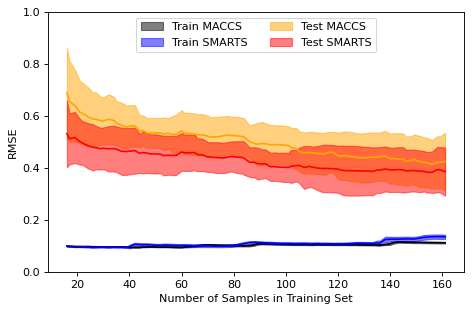

In [7]:
seed = 0

X = Bit_Matrix_Short
X_Maccs = Bit_Matrix_MACCS_Short

y = data[['Normalized Cond']]

k_fold = int(10)

train_indices = [0.0]*k_fold
test_indices = [0.0]*k_fold

Train_Input = [[]]*k_fold
Train_Input_MACCS = [[]]*k_fold
Train_Target = [[]]*k_fold
Test_Input = [[]]*k_fold
Test_Input_MACCS = [[]]*k_fold
Test_Target = [[]]*k_fold
Test_CompStrings = [[]]*k_fold
Test_NernstEinstein = [[]]*k_fold
Test_Temperature = [[]]*k_fold

i = 0
gss = GroupKFold(n_splits=k_fold, shuffle=True, random_state=seed)

for train_idx, test_idx in gss.split(X, y, data['compString']):
    train_indices[i] = train_idx
    test_indices[i] = test_idx

    Train_Input[i] = X.iloc[train_indices[i].tolist(),:].values
    Train_Input_MACCS[i] = X_Maccs.iloc[train_indices[i].tolist(),:].values
    Train_Target[i] = y.iloc[train_indices[i].tolist(),:].values

    Test_Input[i] = X.iloc[test_indices[i].tolist(),:].values
    Test_Input_MACCS[i] = X_Maccs.iloc[test_indices[i].tolist(),:].values
    Test_Target[i] = y.iloc[test_indices[i].tolist(),:].values
    Test_CompStrings[i] = data[['compString']].iloc[test_indices[i].tolist(),:].values
    # Test_Temperature[i] = data[['Temperature']].iloc[test_indices[i].tolist(),:].values
    i += 1


Regressor = SVR(epsilon=0.1, C=10)       
train_size_abs, train_scores, test_scores = learning_curve(Regressor, X, y.to_numpy().ravel(), train_sizes=np.arange(0.1,1,0.01), cv=GroupKFold(n_splits=k_fold), groups=data['compString'], scoring='neg_root_mean_squared_error')


Regressor_MACCS = SVR(epsilon=0.1, C=1000)       
train_size_abs_MACCS, train_scores_MACCS, test_scores_MACCS = learning_curve(Regressor_MACCS, X_Maccs, y.to_numpy().ravel(), train_sizes=np.arange(0.1,1,0.01), cv=GroupKFold(n_splits=k_fold), groups=data['compString'], scoring='neg_root_mean_squared_error')

train_scores = train_scores*-1
test_scores = test_scores*-1

train_scores_MACCS = train_scores_MACCS*-1
test_scores_MACCS = test_scores_MACCS*-1

fig, ax = plt.subplots(num=None, dpi=80, facecolor='w', edgecolor='k')
ax.set_facecolor('w')

plt.plot(train_size_abs_MACCS, train_scores_MACCS.mean(axis=1), c='k')
plt.fill_between(train_size_abs_MACCS, train_scores_MACCS.mean(axis=1) + train_scores_MACCS.std(axis=1), train_scores_MACCS.mean(axis=1) - train_scores_MACCS.std(axis=1), color='k', alpha=0.5, label='Train MACCS')

plt.plot(train_size_abs, train_scores.mean(axis=1), c='b')
plt.fill_between(train_size_abs, train_scores.mean(axis=1) + train_scores.std(axis=1), train_scores.mean(axis=1) - train_scores.std(axis=1), color='b', alpha=0.5, label='Train SMARTS')

plt.plot(train_size_abs_MACCS, test_scores_MACCS.mean(axis=1), c='orange')
plt.fill_between(train_size_abs_MACCS, test_scores_MACCS.mean(axis=1) + test_scores_MACCS.std(axis=1), test_scores_MACCS.mean(axis=1) - test_scores_MACCS.std(axis=1), color='orange', alpha=0.5, label='Test MACCS')

plt.plot(train_size_abs, test_scores.mean(axis=1), c='r')
plt.fill_between(train_size_abs, test_scores.mean(axis=1) + test_scores.std(axis=1), test_scores.mean(axis=1) - test_scores.std(axis=1), color='red', alpha=0.5, label='Test SMARTS')

plt.ylabel('RMSE')
plt.xlabel('Number of Samples in Training Set')
plt.ylim(0,1)
plt.legend(loc=9, ncol=2)

plt.tight_layout()

plt.savefig('../Figures/Training Curve 298 K.png', dpi=150)

plt.show()

# All Temps

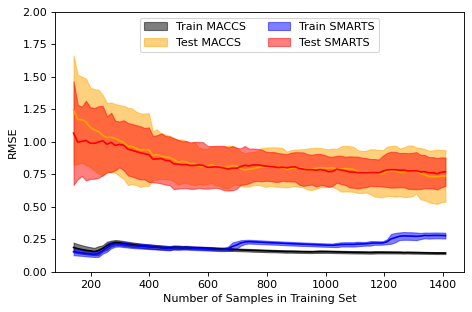

In [8]:
seed = 0

X_T = Bit_Matrix_Short_T
X_T_Maccs = Bit_Matrix_MACCS_Short_T
y_T = data_T[['Normalized Cond']]

k_fold = int(10)

train_indices_T = [0.0]*k_fold
test_indices_T = [0.0]*k_fold

Train_Input_T = [[]]*k_fold
Train_Input_T_MACCS = [[]]*k_fold
Train_Target_T = [[]]*k_fold
Test_Input_T = [[]]*k_fold
Test_Input_T_MACCS = [[]]*k_fold
Test_Target_T = [[]]*k_fold
Test_CompStrings_T = [[]]*k_fold
Test_NernstEinstein_T = [[]]*k_fold
Test_Temperature_T = [[]]*k_fold

i = 0
gss_T = GroupKFold(n_splits=k_fold, shuffle=True, random_state=seed)

for train_idx, test_idx in gss_T.split(X_T, y_T, data_T['compString']):
    train_indices_T[i] = train_idx
    test_indices_T[i] = test_idx

    Train_Input_T[i] = X_T.iloc[train_indices_T[i].tolist(),:].values
    Train_Input_T_MACCS[i] = X_T_Maccs.iloc[train_indices_T[i].tolist(),:].values
    Train_Target_T[i] = y_T.iloc[train_indices_T[i].tolist(),:].values

    Test_Input_T[i] = X_T.iloc[test_indices_T[i].tolist(),:].values
    Test_Input_T_MACCS[i] = X_T_Maccs.iloc[test_indices_T[i].tolist(),:].values
    Test_Target_T[i] = y_T.iloc[test_indices_T[i].tolist(),:].values
    Test_CompStrings_T[i] = data_T[['compString']].iloc[test_indices_T[i].tolist(),:].values
    Test_Temperature[i] = data_T[['Temperature']].iloc[test_indices_T[i].tolist(),:].values
    i += 1


Regressor = SVR(epsilon=0.1, C=1000)       
train_size_abs, train_scores, test_scores = learning_curve(Regressor, X_T.to_numpy(), y_T.to_numpy().ravel(), train_sizes=np.arange(0.1,1,0.01), cv=GroupKFold(n_splits=k_fold), groups=data_T['compString'], scoring='neg_root_mean_squared_error')

Regressor_MACCS = SVR(epsilon=0.1, C=1000)       
train_size_abs_MACCS, train_scores_MACCS, test_scores_MACCS = learning_curve(Regressor, X_T_Maccs.to_numpy(), y_T.to_numpy().ravel(), train_sizes=np.arange(0.1,1,0.01), cv=GroupKFold(n_splits=k_fold), groups=data_T['compString'], scoring='neg_root_mean_squared_error')

train_scores = train_scores*-1
test_scores = test_scores*-1

train_scores_MACCS = train_scores_MACCS*-1
test_scores_MACCS = test_scores_MACCS*-1

fig, ax = plt.subplots(num=None, dpi=80, facecolor=None, edgecolor='k')
ax.set_facecolor('None')

plt.plot(train_size_abs_MACCS, train_scores_MACCS.mean(axis=1), c='k')
plt.fill_between(train_size_abs_MACCS, train_scores_MACCS.mean(axis=1) + train_scores_MACCS.std(axis=1), train_scores_MACCS.mean(axis=1) - train_scores_MACCS.std(axis=1), color='k', alpha=0.5, label='Train MACCS')

plt.plot(train_size_abs, test_scores_MACCS.mean(axis=1), c='orange')
plt.fill_between(train_size_abs, test_scores_MACCS.mean(axis=1) + test_scores_MACCS.std(axis=1), test_scores_MACCS.mean(axis=1) - test_scores_MACCS.std(axis=1), color='orange', alpha=0.5, label='Test MACCS')

plt.plot(train_size_abs, train_scores.mean(axis=1), c='b')
plt.fill_between(train_size_abs, train_scores.mean(axis=1) + train_scores.std(axis=1), train_scores.mean(axis=1) - train_scores.std(axis=1), color='b', alpha=0.5, label='Train SMARTS')

plt.plot(train_size_abs, test_scores.mean(axis=1), c='r')
plt.fill_between(train_size_abs, test_scores.mean(axis=1) + test_scores.std(axis=1), test_scores.mean(axis=1) - test_scores.std(axis=1), color='red', alpha=0.5, label='Test SMARTS')

plt.ylabel('RMSE')
plt.xlabel('Number of Samples in Training Set')
plt.ylim(0,2)
plt.legend(loc=9, ncol=2)

plt.tight_layout()

plt.savefig('../Figures/Training Curve All Temps.png', dpi=150)

plt.show()